## Aesha's Contribution

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import gym
from gym import spaces

c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Environment with Sentence-BERT Embeddings

In [5]:
class PromptOptimizationEnv(gym.Env):
    def __init__(self, embedding_model, embedding_dim=384):
        super(PromptOptimizationEnv, self).__init__()
        self.embedding_model = embedding_model
        self.embedding_dim = embedding_dim
        self.prompts = [
            "What are the benefits of meditation?",
            "Explain quantum computing to a 5-year-old.",
            "Why is the sky blue?",
            "Tell me a fun fact about space.",
            "What causes inflation in an economy?",
            "Describe the health effects of junk food.",
            "What makes diamonds so valuable?",
            "How does climate change affect agriculture?",
            "Give a summary of World War II.",
            "Why do cats purr?"
        ]
        self.observation_space = spaces.Box(low=-1, high=1, shape=(self.embedding_dim,), dtype=np.float32)
        self.action_space = spaces.Box(low=-0.1, high=0.1, shape=(self.embedding_dim,), dtype=np.float32)

    def reset(self):
        self.original_prompt = random.choice(self.prompts)
        self.embedding = self._get_embedding(self.original_prompt)
        return self.embedding

    def step(self, action):
        modified_embedding = self.embedding + action
        reward = self._calculate_reward(self.embedding, modified_embedding)
        done = True
        return self.embedding, reward, done, {}

    def _get_embedding(self, prompt):
        return self.embedding_model.encode(prompt)

    def _calculate_reward(self, original, modified):
        sim = cosine_similarity([original], [modified])[0][0]
        redundancy_penalty = 0.5 * np.mean(modified ** 2)
        return sim - redundancy_penalty

##  Actor Network

In [7]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Actor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, action_dim), nn.Tanh()
        )

    def forward(self, state):
        return self.net(state)

## Critic Network

In [10]:
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, state, action):
        return self.net(torch.cat([state, action], dim=1))

## DDPG Agent

In [11]:
class DDPGAgent:
    def __init__(self, state_dim, action_dim, gamma=0.99, tau=0.005):
        self.actor = Actor(state_dim, action_dim)
        self.target_actor = Actor(state_dim, action_dim)
        self.critic = Critic(state_dim, action_dim)
        self.target_critic = Critic(state_dim, action_dim)

        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=1e-4)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=1e-3)

        self.replay_buffer = deque(maxlen=10000)
        self.batch_size = 64
        self.gamma = gamma
        self.tau = tau
        self._soft_update(1.0)

    def select_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            return self.actor(state).squeeze(0).numpy()

    def store_transition(self, s, a, r, s_):
        self.replay_buffer.append((s, a, r, s_))

    def train(self):
        if len(self.replay_buffer) < self.batch_size:
            return

        batch = random.sample(self.replay_buffer, self.batch_size)
        states, actions, rewards, next_states = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.FloatTensor(np.array(actions))
        rewards = torch.FloatTensor(np.array(rewards)).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states))

        next_actions = self.target_actor(next_states)
        target_q = self.target_critic(next_states, next_actions)
        q_target = rewards + self.gamma * target_q.detach()
        q_value = self.critic(states, actions)
        critic_loss = nn.MSELoss()(q_value, q_target)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        actor_loss = -self.critic(states, self.actor(states)).mean()

        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        self._soft_update(self.tau)

    def _soft_update(self, tau):
        for target, main in zip(self.target_actor.parameters(), self.actor.parameters()):
            target.data.copy_(tau * main.data + (1 - tau) * target.data)
        for target, main in zip(self.target_critic.parameters(), self.critic.parameters()):
            target.data.copy_(tau * main.data + (1 - tau) * target.data)

##  Train the Agent

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Episode 000 | Latest Reward: 0.7845 | Avg (Last 50): 0.7845 | Best So Far: 0.7845
Episode 010 | Latest Reward: 0.7912 | Avg (Last 50): 0.7868 | Best So Far: 0.8066


c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 

Episode 020 | Latest Reward: 0.7912 | Avg (Last 50): 0.7843 | Best So Far: 0.8066
Episode 030 | Latest Reward: 0.7712 | Avg (Last 50): 0.7838 | Best So Far: 0.8066


c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 

...

c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 

Episode 480 | Latest Reward: 0.7160 | Avg (Last 50): 0.7315 | Best So Far: 0.8066


c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 

Episode 490 | Latest Reward: 0.7149 | Avg (Last 50): 0.7297 | Best So Far: 0.8066


c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
c:\Users\User\Desktop\CV\assignment_ver2\pytorch1\Lib\site-packages\torch\nn\modules\module.py:1762: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 

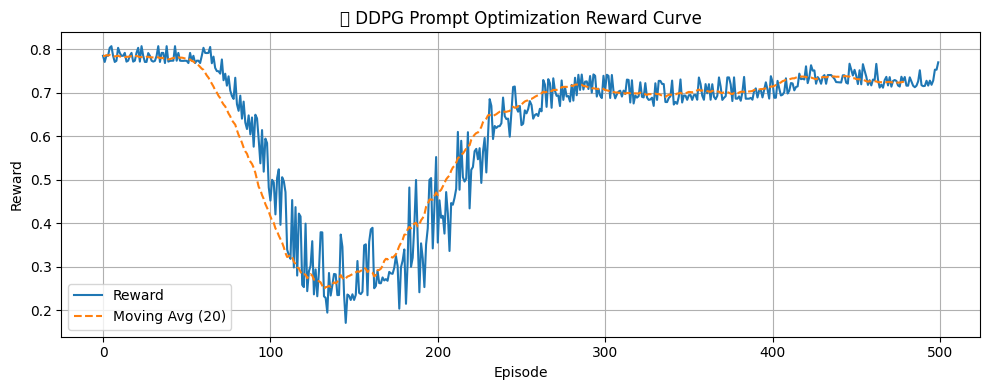

In [13]:
# -------- Train the Agent with Progress Logging --------
if __name__ == "__main__":
    embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
    env = PromptOptimizationEnv(embedding_model)
    agent = DDPGAgent(state_dim=384, action_dim=384)
    reward_log = []

    best_reward = -float("inf")

    for episode in range(500):
        state = env.reset()
        action = agent.select_action(state)
        next_state, reward, done, _ = env.step(action)

        reward_log.append(reward)
        best_reward = max(best_reward, reward)
        agent.store_transition(state, action, reward, next_state)
        agent.train()

        # Print every 10 episodes
        if episode % 10 == 0:
            last_50 = reward_log[-50:] if len(reward_log) >= 50 else reward_log
            print(f"Episode {episode:03d} | "
                  f"Latest Reward: {reward:.4f} | "
                  f"Avg (Last 50): {np.mean(last_50):.4f} | "
                  f"Best So Far: {best_reward:.4f}")

    # -------- Plot Reward Curve with Moving Average --------
    plt.figure(figsize=(10, 4))
    plt.plot(reward_log, label="Reward")
    ma = np.convolve(reward_log, np.ones(20)/20, mode='valid')
    plt.plot(ma, label="Moving Avg (20)", linestyle='--')
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title(" DDPG Prompt Optimization Reward Curve")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()